# Clasificacion con Spotify Tracks Dataset

En este notebook vas a construir modelos de clasificacion para predecir caracteristicas de canciones usando audio features de Spotify.

El dataset contiene 114,000 canciones con las siguientes columnas relevantes:

| Columna | Descripcion |
|---|---|
| `popularity` | Popularidad de 0 a 100 |
| `duration_ms` | Duracion en milisegundos |
| `danceability` | Que tan bailable es la cancion (0-1) |
| `energy` | Intensidad y actividad percibida (0-1) |
| `loudness` | Volumen medio en dB |
| `speechiness` | Presencia de palabras habladas (0-1) |
| `acousticness` | Probabilidad de ser acustica (0-1) |
| `instrumentalness` | Probabilidad de no tener vocals (0-1) |
| `liveness` | Probabilidad de ser grabacion en vivo (0-1) |
| `valence` | Positividad musical (0-1) |
| `tempo` | Velocidad en BPM |
| `explicit` | Si la cancion tiene contenido explicito (True/False) |
| `track_genre` | Genero musical (114 categorias) |

**Dos ejercicios:**
- **Parte A — Clasificacion binaria:** predecir si una cancion es `explicit`
- **Parte B — Clasificacion multiclase:** predecir el genero entre `pop`, `rock`, `hip-hop` y `classical`

---

## 0. Librerias

In [ ]:
# !pip install -q scikit-learn pandas numpy matplotlib seaborn

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
import kagglehub

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

## 1. Carga y exploracion

Carga el archivo `dataset.csv` y revisa su estructura.

Resultado esperado:
```
Shape: (114000, 21)

Nulos por columna:
artists       1
album_name    1
track_name    1
(resto de columnas: 0)
```

In [9]:
# Carga el dataset
path = kagglehub.dataset_download("melissamonfared/spotify-tracks-attributes-and-popularity")
df = pd.read_csv(os.path.join(path, "dataset.csv"))
# Imprime shape
print("Shape:", df.shape)
# Imprime los nulos por columna
nulls = df.isnull().sum()
print("\nNulos por columna:")
print(nulls[nulls > 0])

Shape: (114000, 21)

Nulos por columna:
artists       1
album_name    1
track_name    1
dtype: int64


## 2. Limpieza

Elimina las filas con valores nulos. Son solo 3 filas sobre 114,000 — no hay riesgo de perder informacion relevante.

Resultado esperado:
```
Shape tras limpieza: (113999, 21)
```

In [10]:
# Elimina filas con nulos
df = df.dropna()

# Imprime el shape resultante
print("Shape tras limpieza:", df.shape)

Shape tras limpieza: (113999, 21)


## 3. Analisis exploratorio

Antes de modelar, entiende las dos variables objetivo.

1. Distribucion de `explicit` (cuantas canciones son y no son explicitas)
2. Histograma de las features numericas principales
3. Boxplot de `danceability`, `energy` y `speechiness` agrupados por `explicit`

Resultado esperado para la distribucion:
```
explicit
False    104252
True      9747
```

explicit
False    104252
True       9747
Name: count, dtype: int64


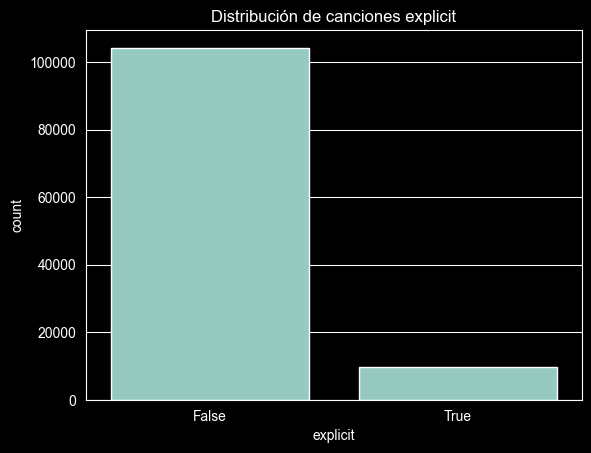

In [11]:
# Conteo de explicit
print(df['explicit'].value_counts())

# Grafico
sns.countplot(data=df, x='explicit')
plt.title("Distribución de canciones explicit")
plt.show()

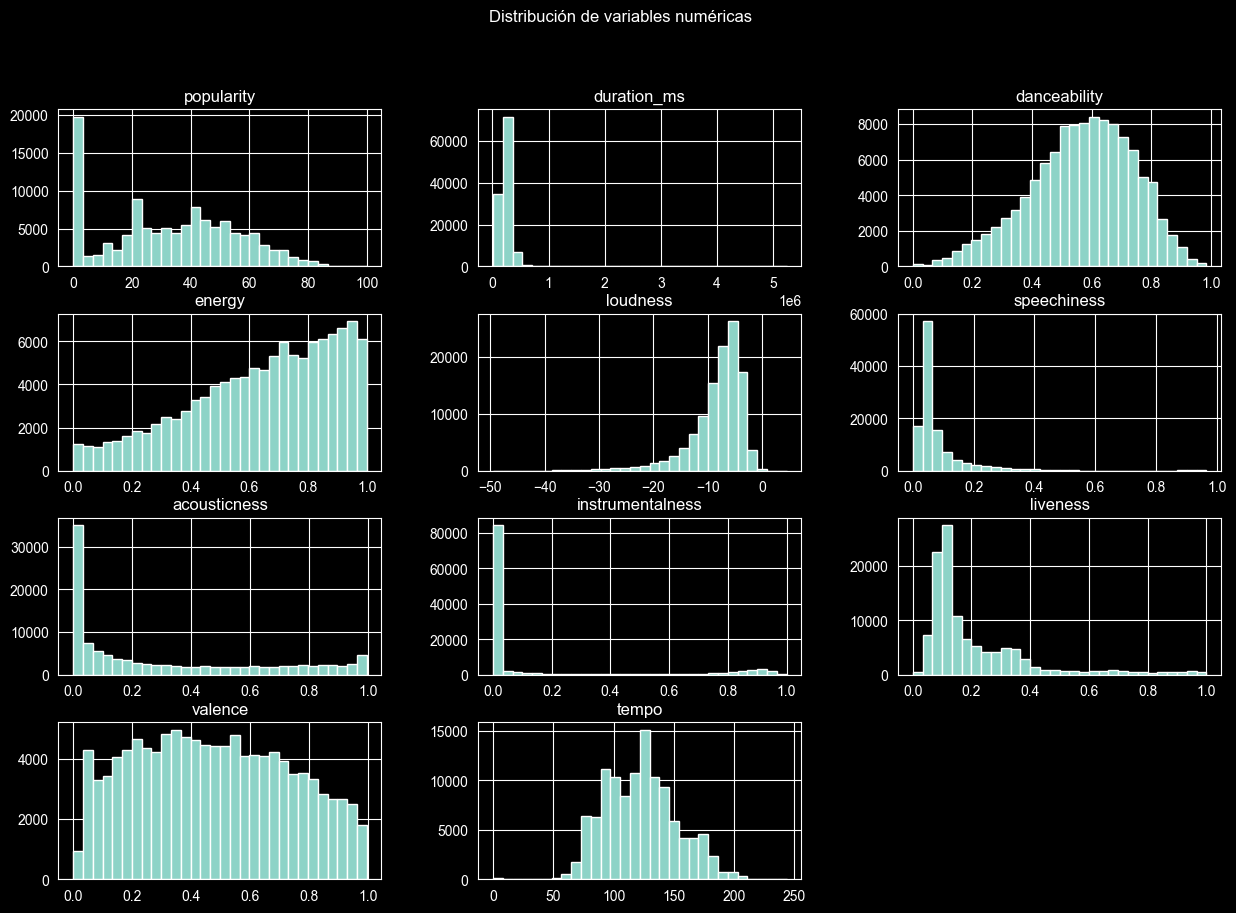

In [12]:
# Seleccion de columnas numericas
num_cols = [
    'popularity', 'duration_ms', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

# Histogramas
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribución de variables numéricas")
plt.show()

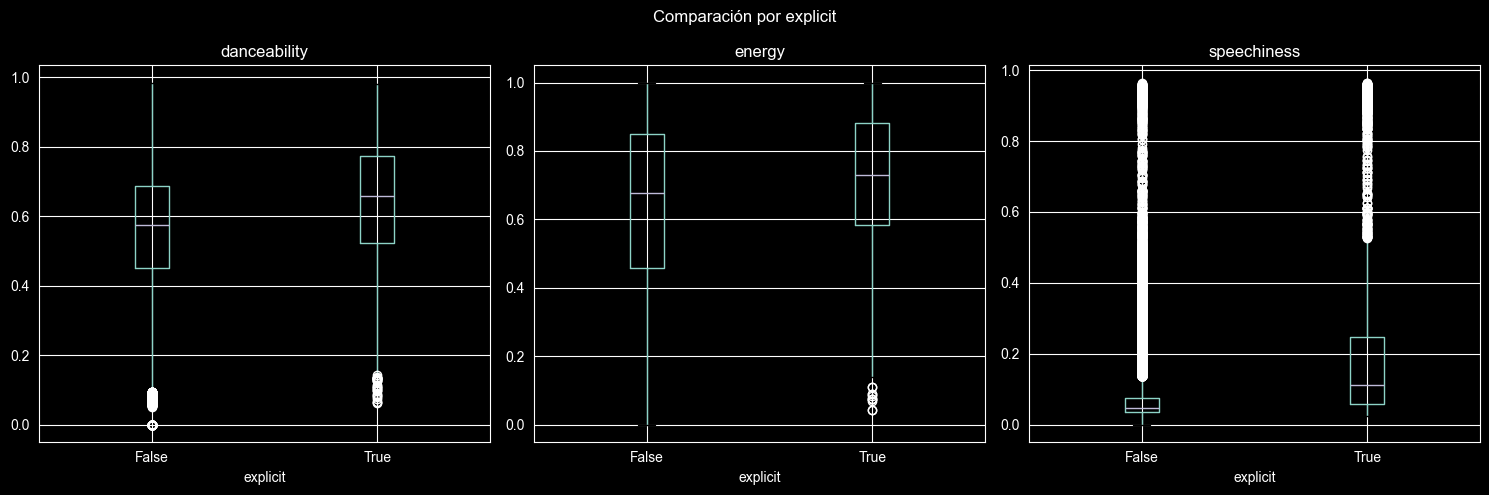

In [13]:
# Boxplot de danceability, energy y speechiness agrupados por explicit
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = ['danceability', 'energy', 'speechiness']

for i, col in enumerate(cols):
    df.boxplot(column=col, by='explicit', ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Comparación por explicit")
plt.tight_layout()
plt.show()

---
# Parte A — Clasificacion Binaria
**Objetivo: predecir si una cancion es `explicit`**

---

## 4. Preparacion de datos (binaria)

Usa estas 11 features para predecir `explicit`:
`popularity`, `duration_ms`, `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`

- Convierte `explicit` a entero (0/1)
- Split 80/20 con `random_state=42` y `stratify=y` (importante por el desbalance)
- Estandariza con `StandardScaler`

Resultado esperado:
```
Clase 0 (no explicit): 104252
Clase 1 (explicit):      9747

X_train: (91199, 11)   X_test: (22800, 11)
```

In [18]:
# Define feature_cols y el target y
# feature
feature_cols = [
    'popularity', 'duration_ms', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]
X = df[feature_cols]
# target
y = df['explicit'].astype(int)

# Imprime la distribucion de clases
print("Distribución de clases:")
counts = y.value_counts()
print(f"Clase 0 (no explicit): {counts[0]}")
print(f"Clase 1 (explicit):      {counts[1]}")

# Haz el split con stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Estandariza
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print
print("\nShapes:")
print("X_train:", X_train.shape, "  X_test:", X_test.shape)

Distribución de clases:
Clase 0 (no explicit): 104252
Clase 1 (explicit):      9747

Shapes:
X_train: (91199, 11)   X_test: (22800, 11)


## 5. Modelo binario

Entrena una `LogisticRegression` con `max_iter=1000` y `random_state=42`.

Resultado esperado:
```
Accuracy: 0.9143

              precision    recall  f1-score   support
           0       0.92      0.99      0.95     20851
           1       0.49      0.09      0.16      1949
    accuracy                           0.91     22800
```

In [19]:
# Entrena LogisticRegression
# Modelo
model = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamiento
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)

# Imprime accuracy y classification_report
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9143

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     20851
           1       0.49      0.09      0.16      1949

    accuracy                           0.91     22800
   macro avg       0.71      0.54      0.56     22800
weighted avg       0.88      0.91      0.89     22800



## 6. Matriz de confusion (binaria)

Visualiza la matriz de confusion con `ConfusionMatrixDisplay`.

Resultado esperado:
```
[[20666   185]
 [ 1769   180]]
```

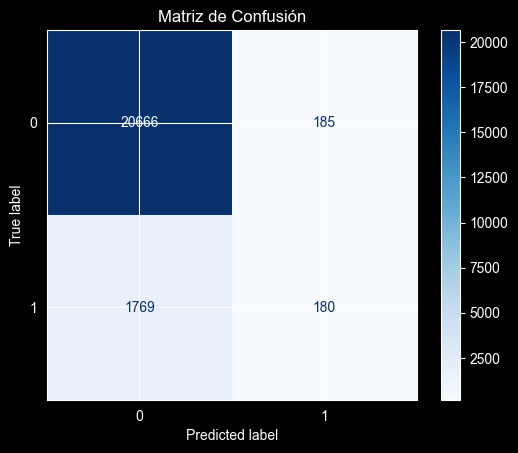

[[20666   185]
 [ 1769   180]]


In [23]:
# Visualiza la matriz de confusion
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualizacion
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Matriz de Confusión")
plt.show()

# Print value
print(cm)

## 7. Analisis del desbalance

El accuracy de 91% parece bueno, pero mira el recall de la clase 1 (explicit): solo 0.09. El modelo casi nunca acierta canciones explicitas.

Esto es un problema de **clases desbalanceadas**. Una solucion simple es usar el parametro `class_weight='balanced'` en `LogisticRegression`, que penaliza mas los errores en la clase minoritaria.

Reentrena el modelo con `class_weight='balanced'` y compara los resultados.

Resultado esperado:
```
              precision    recall  f1-score   support
           0       0.95      0.80      0.87     20851
           1       0.35      0.73      0.47      1949
    accuracy                           0.80     22800
```

Accuracy: 0.7391

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     20851
           1       0.21      0.72      0.32      1949

    accuracy                           0.74     22800
   macro avg       0.59      0.73      0.58     22800
weighted avg       0.90      0.74      0.79     22800



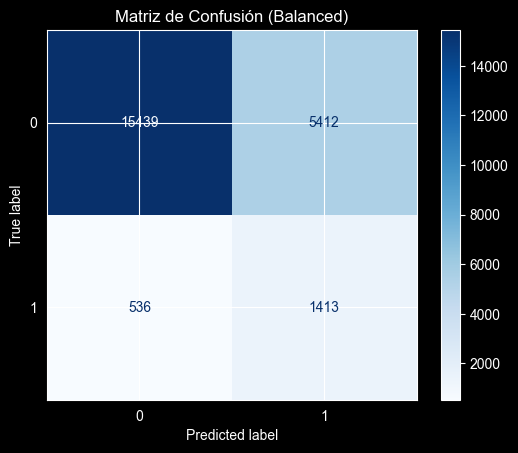

[[15439  5412]
 [  536  1413]]


In [24]:
# Reentrena con class_weight='balanced'
model_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
model_balanced.fit(X_train_scaled, y_train)

y_pred_bal = model_balanced.predict(X_test_scaled)

# Imprime accuracy y classification_report
# Accuracy
acc_bal = accuracy_score(y_test, y_pred_bal)
print(f"Accuracy: {acc_bal:.4f}")

# Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bal))

# Visualiza la nueva matriz de confusion
cm_bal = confusion_matrix(y_test, y_pred_bal)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bal)
disp.plot(cmap='Blues')

plt.title("Matriz de Confusión (Balanced)")
plt.show()

print(cm_bal)

## 8. Coeficientes del modelo

Visualiza los coeficientes del modelo balanceado en un grafico de barras horizontal ordenado de mayor a menor.

Resultado esperado (coeficientes ordenados):
```
speechiness        0.6452
danceability       0.4974
loudness           0.4732
popularity         0.1658
tempo             -0.0362
liveness          -0.0565
energy            -0.0715
duration_ms       -0.3667
instrumentalness  -0.4253
valence           -0.4300
acousticness      -0.4923
```

             feature      coef
5        speechiness  0.810695
2       danceability  0.441663
4           loudness  0.427555
0         popularity  0.170076
3             energy  0.023505
10             tempo -0.027481
8           liveness -0.084494
7   instrumentalness -0.379699
1        duration_ms -0.408657
9            valence -0.445413
6       acousticness -0.522380


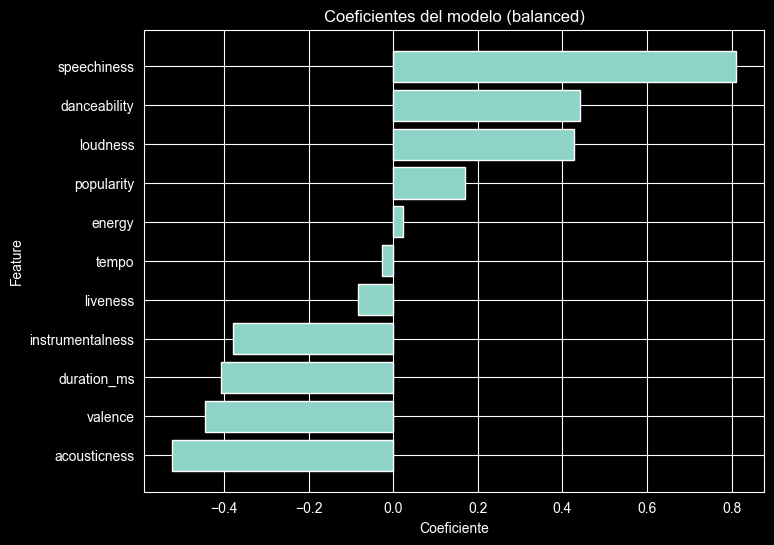

In [25]:
# Grafico de barras horizontal con los coeficientes
# Coeficientes
coef = model_balanced.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': coef
})

# Descending Sort
coef_df = coef_df.sort_values(by='coef', ascending=False)

print(coef_df)

# Horizontal Bar Graph
plt.figure(figsize=(8, 6))
plt.barh(coef_df['feature'], coef_df['coef'])
plt.gca().invert_yaxis()  # 큰 값이 위로 오게
plt.title("Coeficientes del modelo (balanced)")
plt.xlabel("Coeficiente")
plt.ylabel("Feature")
plt.show()

---
# Parte B — Clasificacion Multiclase
**Objetivo: predecir el genero entre `pop`, `rock`, `hip-hop` y `classical`**

---

## 9. Preparacion de datos (multiclase)

Filtra el dataset para quedarte solo con los 4 generos: `pop`, `rock`, `hip-hop`, `classical`. Usa las mismas 11 features.

- Split 80/20 con `random_state=42` y `stratify=y`
- Estandariza con un nuevo `StandardScaler`

Resultado esperado:
```
Distribucion por genero:
classical    1000
hip-hop      1000
pop          1000
rock         1000

X_train: (3200, 11)   X_test: (800, 11)
```

In [26]:
# Filtra el dataset a los 4 generos
# Generos a usar
selected_genres = ['pop', 'rock', 'hip-hop', 'classical']
# Filtrar dataset
df_multi = df[df['track_genre'].isin(selected_genres)].copy()
# Features y target
X = df_multi[feature_cols]
y = df_multi['track_genre']

# Imprime la distribucion
print("Distribucion por genero:")
print(y.value_counts())

# Split y estandarizacion
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Nuevo escalador
scaler_multi = StandardScaler()
X_train_scaled = scaler_multi.fit_transform(X_train)
X_test_scaled = scaler_multi.transform(X_test)
# Shapes
print("\nX_train:", X_train.shape, "  X_test:", X_test.shape)

Distribucion por genero:
track_genre
classical    1000
hip-hop      1000
pop          1000
rock         1000
Name: count, dtype: int64

X_train: (3200, 11)   X_test: (800, 11)


## 10. Modelo multiclase

Entrena una `LogisticRegression` con `max_iter=1000` y `random_state=42`. Sklearn detecta automaticamente que hay mas de 2 clases y usa clasificacion multiclase.

Resultado esperado:
```
Accuracy: 0.7075

              precision    recall  f1-score   support
   classical       0.93      0.93      0.93       200
     hip-hop       0.71      0.70      0.71       200
         pop       0.53      0.49      0.51       200
        rock       0.66      0.70      0.68       200
    accuracy                           0.71       800
```

In [27]:
# Entrena LogisticRegression
# Modelo multiclase
model_multi = LogisticRegression(
    max_iter=1000,
    random_state=42
)
# Entrenamiento
model_multi.fit(X_train_scaled, y_train)
# Predicciones
y_pred = model_multi.predict(X_test_scaled)

# Imprime accuracy y classification_report
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7075

Classification Report:
              precision    recall  f1-score   support

   classical       0.93      0.93      0.93       200
     hip-hop       0.71      0.70      0.71       200
         pop       0.53      0.49      0.51       200
        rock       0.66      0.70      0.68       200

    accuracy                           0.71       800
   macro avg       0.71      0.71      0.71       800
weighted avg       0.71      0.71      0.71       800



## 11. Matriz de confusion (multiclase)

Visualiza la matriz de confusion. Con 4 clases puedes ver exactamente que pares de generos se confunden mas.

Resultado esperado:
```
              pop   rock  hip-hop  classical
pop          [ 99    43      47       11]
rock         [ 45   141      10        4]
hip-hop      [ 33    26     141        0]
classical    [ 11     4       0      185]
```

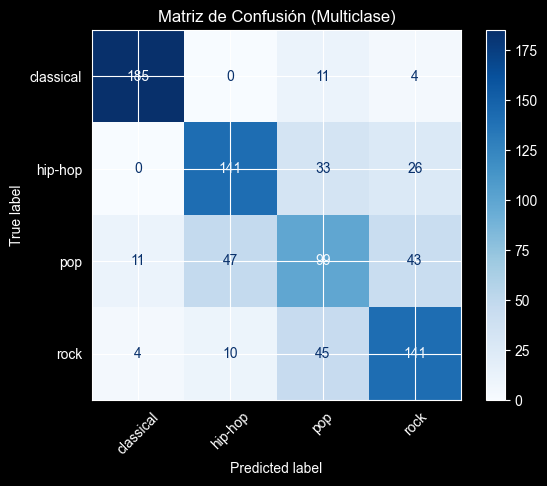

[[185   0  11   4]
 [  0 141  33  26]
 [ 11  47  99  43]
 [  4  10  45 141]]


In [28]:
# Visualiza la matriz de confusion con ConfusionMatrixDisplay
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model_multi.classes_)

# Visualizacion
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_multi.classes_
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusión (Multiclase)")
plt.xticks(rotation=45)
plt.show()

# print value
print(cm)

## 12. Reflexion final

Responde en esta celda:

1. El accuracy del modelo binario sin balancear es 91%, pero el modelo balanceado baja a 80%. Cual es mejor y por que depende del contexto?
2. Por que `speechiness` tiene el coeficiente positivo mas alto para predecir `explicit`? Tiene sentido musicalmente?
3. `classical` se clasifica con precision y recall de 0.93, mientras `pop` solo llega a 0.53. Por que crees que classical es tan facil de separar y pop tan dificil?
4. Que generos se confunden mas entre si segun la matriz de confusion? Por que tiene sentido?
5. El baseline de la clasificacion multiclase es 0.25 (adivinar al azar entre 4 clases). El modelo llega a 0.71. Es un resultado razonable con solo features de audio?

1. El modelo sin balancear tiene mayor accuracy (91%), pero no detecta bien las canciones explícitas (recall muy bajo). El modelo balanceado baja a 80%, pero mejora mucho la detección de la clase minoritaria. Dependiendo del contexto, si es importante detectar contenido explícito, el modelo balanceado es mejor.

---

2. speechiness mide la presencia de palabras habladas.
Las canciones con más contenido hablado (como rap o hip-hop) tienen más probabilidad de incluir lenguaje explícito. Por eso tiene el coeficiente más alto, y sí, tiene sentido musicalmente.

---

3. El género classical es más fácil de separar porque tiene características muy distintas (alta acousticness, instrumentalness, baja energía). En cambio, pop comparte características con muchos otros géneros como rock o hip-hop, por eso es más difícil de clasificar.

---

4. Los géneros que más se confunden son pop con rock y pop con hip-hop. Tiene sentido porque comparten muchas características de audio y estilos modernos.

---

5. Sí, es un buen resultado. Pasar de un baseline de 0.25 a 0.71 indica que el modelo aprende patrones útiles solo con features de audio, aunque todavía hay margen de mejora.